## Overview

Ask a home buyer to describe their dream house, and they probably won't begin with the height
of the basement ceiling or the proximity to an east-west railroad. But this playground
competition's dataset proves that much more influences price negotiations than the number of
bedrooms or a white-picket fence.

With 79 explanatory variables describing (almost) every aspect of residential homes in Ames,
Iowa, this competition challenges you to predict the final price of each home

## Acknowledgments

The Ames Housing dataset was compiled by Dean De Cock for use in data science education. It's
an incredible alternative for data scientists looking for a modernized and expanded version of the
often cited Boston Housing dataset.

You can find the dataset here (https://www.kaggle.com/c/house-prices-advanced-regression-techniques/data).

## Files

1. `train.csv` — the training set.
2. `test.csv` — the test set.
3. `data_description.txt` — full description of each column, originally prepared by Dean De Cock but lightly edited to match the column names used here.

So lets begin with complete EDA…

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path

## Load Data

In [61]:
# Added: support local Jupyter/VS Code and Kaggle dataset paths.
DATA_DIR = Path("data")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
train = pd.read_csv(DATA_DIR / 'train.csv')
test = pd.read_csv(DATA_DIR / 'test.csv')
n_train = len(train)
print('Train Shape: ', train.shape)
print('Test Shape: ', test.shape)

Train Shape:  (1460, 81)
Test Shape:  (1459, 80)


Train has 81 columns (79 features + id and target SalePrice) and 1460 entries.

Test has 80 columns (79 features + id) and 1459 entries.

In [62]:
print(train.info())
display(train.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [63]:
print(test.info())
display(test.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   object 
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   object 
 6   Alley          107 non-null    object 
 7   LotShape       1459 non-null   object 
 8   LandContour    1459 non-null   object 
 9   Utilities      1457 non-null   object 
 10  LotConfig      1459 non-null   object 
 11  LandSlope      1459 non-null   object 
 12  Neighborhood   1459 non-null   object 
 13  Condition1     1459 non-null   object 
 14  Condition2     1459 non-null   object 
 15  BldgType       1459 non-null   object 
 16  HouseStyle     1459 non-null   object 
 17  OverallQual    1459 non-null   int64  
 18  OverallC

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


## Check for NULL values

### Train Data

In [64]:
print(train.isnull().sum())

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64


<Axes: >

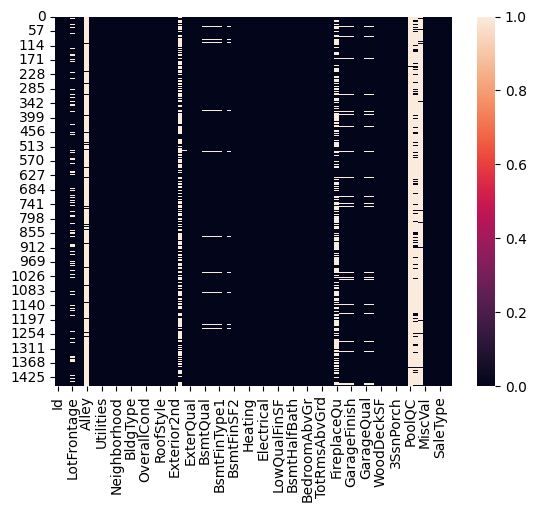

In [65]:
sns.heatmap(train.isnull())

### Test Data

In [66]:
print(test.isnull().sum())

Id                 0
MSSubClass         0
MSZoning           4
LotFrontage      227
LotArea            0
                ... 
MiscVal            0
MoSold             0
YrSold             0
SaleType           1
SaleCondition      0
Length: 80, dtype: int64


<Axes: >

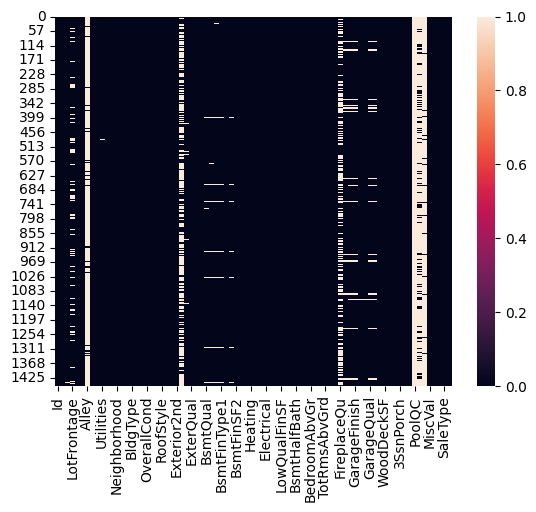

In [67]:
sns.heatmap(test.isnull())

## Handling NULL data

We can see that ‘Alley’, ‘PoolQC’, ‘Fence’ and ‘MiscFeature’ columns have more than 70% of null values in both train and test data. So, we will drop these columns.

Also, we will drop ‘Id’ column. For non-categorical columns, we will handle null values by filling mean of the column.

For categorical columns, we will handle null values by filling mode of the column.

### For Train Data

In [68]:
cat_col_train = ['FireplaceQu', 'GarageType', 'GarageFinish', 'MasVnrType', 'BsmtQual',
                 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'FireplaceQu',
                 'GarageQual', 'GarageCond']
ncat_col_train = ['LotFrontage', 'GarageYrBlt', 'MasVnrArea']

for i in cat_col_train:
    train[i] = train[i].fillna(train[i].mode()[0])
for j in ncat_col_train:
    train[j] = train[j].fillna(train[j].mean())

### For Test Data

In [69]:
cat_col_test = ['FireplaceQu', 'GarageType', 'GarageFinish', 'MasVnrType', 'BsmtQual',
                'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'FireplaceQu',
                'GarageQual', 'GarageCond', 'MSZoning', 'Utilities', 'Exterior1st',
                'Exterior2nd', 'KitchenQual', 'Functional', 'SaleType']
ncat_col_test = ['LotFrontage', 'GarageYrBlt', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
                 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'GarageCars',
                 'GarageArea']

for i in cat_col_test:
    test[i] = test[i].fillna(test[i].mode()[0])
for j in ncat_col_test:
    test[j] = test[j].fillna(test[j].mean())

### Drop Columns

In [70]:
to_drop = ['Id', 'Alley', 'PoolQC', 'Fence', 'MiscFeature']
for k in to_drop:
    train.drop([k], axis=1, inplace=True)
    test.drop([k], axis=1, inplace=True)

<Axes: >

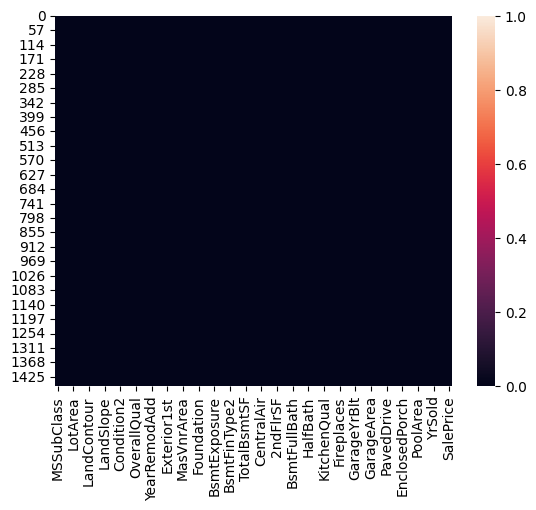

In [71]:
sns.heatmap(train.isnull())

<Axes: >

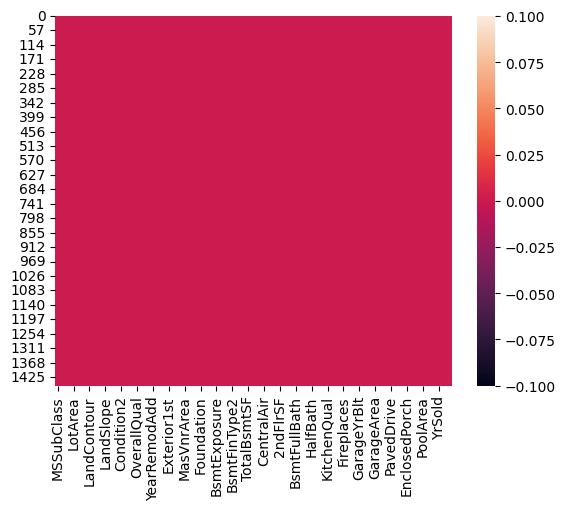

In [72]:
sns.heatmap(test.isnull())

In [73]:
print('Train Shape: ', train.shape)
print('Test Shape: ', test.shape)

Train Shape:  (1460, 76)
Test Shape:  (1459, 75)


It is observed that for some columns in train data few categories are not present but available in test data. So, we will concat test data to train data, then perform one hot encoding on all categorical columns.

In [74]:
final_df = pd.concat([train, test], axis=0)
final_df.shape

(2919, 76)

In [75]:
all_cat_col = ['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
               'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
               'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd',
               'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
               'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC',
               'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu',
               'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive',
               'SaleType', 'SaleCondition']

In [76]:
def cat_onehot_encoding(multicol):
    # Original algorithm; dummy names and duplicate removal are preserved.
    df_final = final_df
    i = 0
    for fields in multicol:
        print(fields)
        df1 = pd.get_dummies(final_df[fields], drop_first=True, dtype=int)
        final_df.drop([fields], axis=1, inplace=True)
        if i == 0:
            df_final = df1.copy()
        else:
            df_final = pd.concat([df_final, df1], axis=1)
        i = i + 1
    df_final = pd.concat([final_df, df_final], axis=1)
    return df_final

final_df = cat_onehot_encoding(all_cat_col)

MSZoning
Street
LotShape
LandContour
Utilities
LotConfig
LandSlope
Neighborhood
Condition1
Condition2
BldgType
HouseStyle
RoofStyle
RoofMatl
Exterior1st
Exterior2nd
MasVnrType
ExterQual
ExterCond
Foundation
BsmtQual
BsmtCond
BsmtExposure
BsmtFinType1
BsmtFinType2
Heating
HeatingQC
CentralAir
Electrical
KitchenQual
Functional
FireplaceQu
GarageType
GarageFinish
GarageQual
GarageCond
PavedDrive
SaleType
SaleCondition


In [77]:
final_df.shape

(2919, 236)

In [78]:
final_df = final_df.loc[:, ~final_df.columns.duplicated()]
final_df.shape

(2919, 176)

Let's now divide our data to train and test data.

In [79]:
# Original split position: 1460. Use the number read from train.csv.
df_train = final_df.iloc[:n_train, :].copy()
df_test = final_df.iloc[n_train:, :].copy()
df_test.drop(['SalePrice'], axis=1, inplace=True)
print('Train Shape: ', df_train.shape)
print('Test Shape: ', df_test.shape)

Train Shape:  (1460, 176)
Test Shape:  (1459, 175)


## Training Data

In [80]:
x_train = df_train.drop(['SalePrice'], axis=1)
y_train = df_train['SalePrice']

## XGBoost

In [81]:
import xgboost

xgb_model = xgboost.XGBRegressor(device='cuda',
                                 n_jobs=-1)
xgb_model.fit(x_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,'cuda'
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [82]:
param = {
    'n_estimators': [100, 500, 900, 1100, 1500],
    'max_depth': [2, 3, 5, 10, 15],
    'learning_rate': [0.05, 0.1, 0.15, 0.2],
    'min_child_weight': [1, 2, 3, 4],
    'booster': ['gbtree', 'gblinear'],
    'base_score': [0.25, 0.5, 0.75, 1],
}

In [83]:
from sklearn.model_selection import RandomizedSearchCV

random_cv = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param,
    cv=5, n_iter=50,
    scoring='neg_root_mean_squared_error', n_jobs=-1,
    verbose=5, return_train_score=True, random_state=42,
)
random_cv.fit(x_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'base_score': [0.25, 0.5, ...], 'booster': ['gbtree', 'gblinear'], 'learning_rate': [0.05, 0.1, ...], 'max_depth': [2, 3, ...], ...}"
,n_iter,50
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,5
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [84]:
print("Best parameters:")
print(random_cv.best_params_)

print("Best RMSE:")
print(-random_cv.best_score_)

Best parameters:
{'n_estimators': 900, 'min_child_weight': 1, 'max_depth': 2, 'learning_rate': 0.1, 'booster': 'gbtree', 'base_score': 0.25}
Best RMSE:
25683.735291736888


In [85]:
random_cv.best_estimator_

,objective,'reg:squarederror'
,base_score,0.25
,booster,'gbtree'
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,'cuda'
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


### Fit the selected configuration from the PDF

Bản gốc khởi tạo lại cấu hình cố định sau khi tìm kiếm. Ô dưới giữ cách làm đó; kết quả tìm kiếm trong lần chạy của bạn có thể chọn cấu hình khác.

In [86]:
# Same training configuration as the PDF; omit obsolete/empty options:
# gpu_id=-1, interaction_constraints='', monotone_constraints='()', verbosity=None.
xgb_model = xgboost.XGBRegressor(
    base_score=0.25, booster='gbtree', colsample_bylevel=1,
    colsample_bynode=1, colsample_bytree=1, gamma=0,
    importance_type='gain', learning_rate=0.1,
    max_delta_step=0, max_depth=2, min_child_weight=1,
    n_estimators=900, n_jobs=-1, num_parallel_tree=1,
    objective='reg:squarederror', random_state=0, reg_alpha=0,
    reg_lambda=1, scale_pos_weight=1, subsample=1,
    tree_method='hist', validate_parameters=True,
    device='cuda',eval_metric='rmse'
)
# xgb_model.fit(x_train, y_train)

In [87]:
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.2,
    random_state=42
)

xgb_model.fit(
    X_tr,
    y_tr,
    eval_set=[
        (X_tr, y_tr),
        (X_val, y_val)
    ],
    verbose=False
)

,objective,'reg:squarederror'
,base_score,0.25
,booster,'gbtree'
,callbacks,None
,colsample_bylevel,1
,colsample_bynode,1
,colsample_bytree,1
,device,'cuda'
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'rmse'


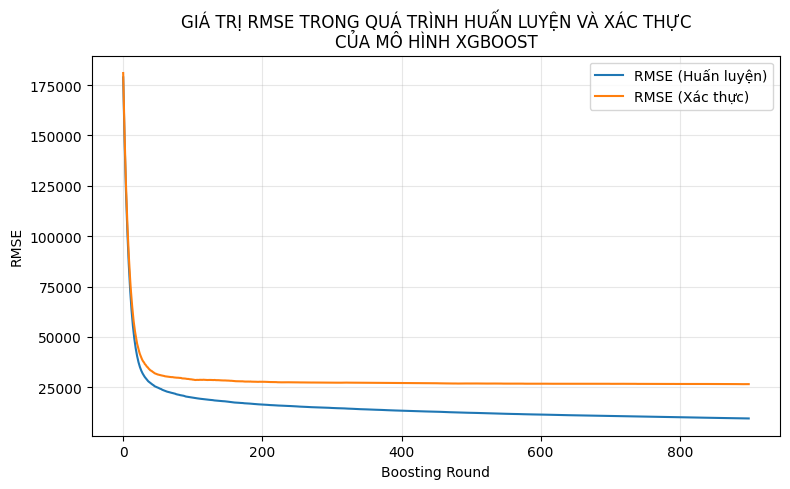

In [88]:
import matplotlib.pyplot as plt

results = xgb_model.evals_result()

train_rmse = results['validation_0']['rmse']
val_rmse = results['validation_1']['rmse']

plt.figure(figsize=(8, 5))

plt.plot(train_rmse, label='RMSE (Huấn luyện)')
plt.plot(val_rmse, label='RMSE (Xác thực)')

plt.xlabel('Boosting Round')
plt.ylabel('RMSE')

plt.title(
    'GIÁ TRỊ RMSE TRONG QUÁ TRÌNH HUẤN LUYỆN VÀ XÁC THỰC\n'
    'CỦA MÔ HÌNH XGBOOST'
)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

#lưu biểu đồ
plt.savefig(OUTPUT_DIR / 'xgb_rmse_plot.png', dpi=300)

plt.show()


In [89]:
from sklearn.metrics import mean_squared_error
import numpy as np

y_pred_xgb = xgb_model.predict(X_val)

rmse_xgb = np.sqrt(
    mean_squared_error(y_val, y_pred_xgb)
)

print(f"XGBoost RMSE: {rmse_xgb:.4f}")

XGBoost RMSE: 26558.1314


### Save Model

In [90]:
f = OUTPUT_DIR / 'xgb_model.pkl'
with open(f, 'wb') as model_file:
    pickle.dump(xgb_model, model_file)
print(f'Đã lưu mô hình XGBoost: {f.resolve()}')

Đã lưu mô hình XGBoost: D:\learn_coding\ML\Team\week_2\lab02\code\outputs\xgb_model.pkl


### Predictions

In [91]:
pred_xgb = xgb_model.predict(df_test)
print(pred_xgb.shape)

(1459,)


### Submission

In [92]:
sub_df = pd.read_csv(DATA_DIR / 'sample_submission.csv')
sub_df['SalePrice'] = pred_xgb
output_file = OUTPUT_DIR / 'sample_sub_xgb.csv'
sub_df.to_csv(output_file, index=False)
print(f'Đã lưu submission XGBoost: {output_file.resolve()}')

Đã lưu submission XGBoost: D:\learn_coding\ML\Team\week_2\lab02\code\outputs\sample_sub_xgb.csv


## Decision Tree

> Tài liệu dùng `DecisionTreeClassifier`; giữ nguyên để đối chiếu. Mô hình này xem từng mức giá là một lớp, không phải cách mô hình hóa hồi quy giá nhà thông thường.

In [93]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_tr, y_tr)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


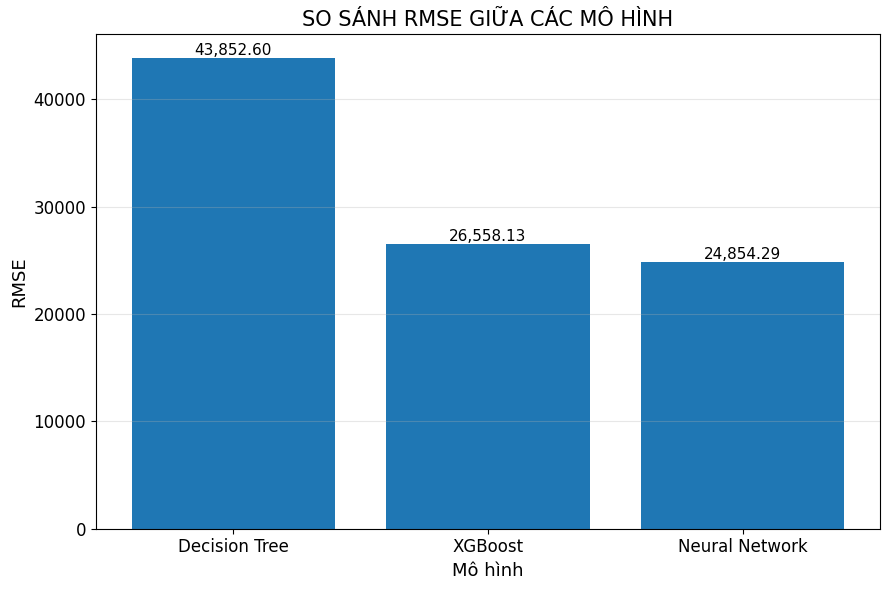

In [94]:
import matplotlib.pyplot as plt

models = [
    'Decision Tree',
    'XGBoost',
    'Neural Network'
]

rmse_values = [
    rmse_dt,
    rmse_xgb,
    rmse_nn
]

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.bar(models, rmse_values)

# Nhãn trục
ax.set_xlabel('Mô hình', fontsize=13)
ax.set_ylabel('RMSE', fontsize=13)

# Tiêu đề
ax.set_title(
    'SO SÁNH RMSE GIỮA CÁC MÔ HÌNH',
    fontsize=15
)

# Tăng kích thước chữ trên trục X và Y
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

# Hiển thị số RMSE trên đầu mỗi cột
for bar, value in zip(bars, rmse_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{value:,.2f}',
        ha='center',
        va='bottom',
        fontsize=11
    )

ax.grid(axis='y', alpha=0.3)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR / 'model_rmse_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Predictions

In [95]:
pred_dt = dt_model.predict(df_test)
print(pred_dt.shape)

(1459,)


### Submissions

In [96]:
sub_df = pd.read_csv(DATA_DIR / 'sample_submission.csv')
sub_df['SalePrice'] = pred_dt
output_file = OUTPUT_DIR / 'sample_sub_dt.csv'
sub_df.to_csv(output_file, index=False)
print(f'Đã lưu submission Decision Tree: {output_file.resolve()}')

Đã lưu submission Decision Tree: D:\learn_coding\ML\Team\week_2\lab02\code\outputs\sample_sub_dt.csv


## Artificial Neural Network

In [97]:
import keras
from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout

# Compatibility: the original uses `from keras import backend as k`.
try:
    from keras import ops as k
except ImportError:
    from keras import backend as k

def root_mean_squared_error(y_true, y_pred):
    return k.sqrt(k.mean(k.square(y_pred - y_true)))

### Model

In [98]:
nn_model = Sequential()
# Original input_dim = 176; use the actual number of encoded features.
nn_model.add(Dense(50, kernel_initializer='he_uniform', activation='relu',
                   input_dim=x_train.shape[1]))
nn_model.add(Dense(25, kernel_initializer='he_uniform', activation='relu'))
nn_model.add(Dense(50, kernel_initializer='he_uniform', activation='relu'))
nn_model.add(Dense(1, kernel_initializer='he_uniform'))
nn_model.compile(loss=root_mean_squared_error, optimizer='Adamax')

d:\learn_coding\ML\Team\.venv\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [99]:
# nn_model.fit(
#     x_train.values, y_train.values,
#     validation_split=0.25, batch_size=10, epochs=1000,
# )

In [100]:
history = nn_model.fit(
    X_tr.values,
    y_tr.values,
    validation_data=(X_val.values, y_val.values),
    batch_size=10,
    epochs=1000,
    verbose=1
)

Epoch 1/1000
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 183772.7344 - val_loss: 161439.0781
Epoch 2/1000
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 105684.3594 - val_loss: 69194.9531
Epoch 3/1000
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 67087.7188 - val_loss: 66323.8516
Epoch 4/1000
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 64932.2188 - val_loss: 64762.0195
Epoch 5/1000
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 63154.2891 - val_loss: 63383.5000
Epoch 6/1000
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 61690.6797 - val_loss: 61951.3906
Epoch 7/1000
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 60536.5625 - val_loss: 60671.1914
Epoch 8/1000
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 59565.2461 - val_loss: 59521.3203
Epoch 9/1000
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 58095.9258 - val_loss: 58409.9727
Epoch 10/1000
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 56031.1289 - val_loss: 57250.8047
Epoch 11/1000
117/117 ━━━━━━━━━━━━━━

In [101]:
from sklearn.metrics import mean_squared_error
import numpy as np

y_pred_nn = nn_model.predict(X_val.values).flatten()

rmse_nn = np.sqrt(
    mean_squared_error(y_val, y_pred_nn)
)

print(f"Neural Network RMSE: {rmse_nn:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Neural Network RMSE: 28169.1433


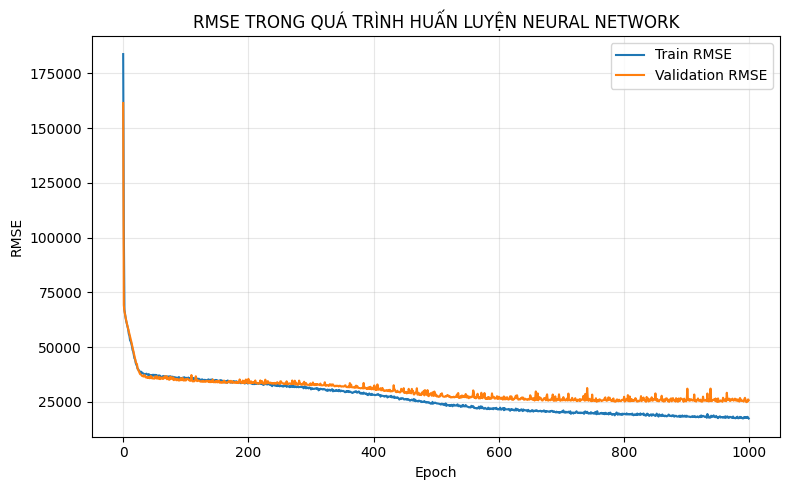

In [102]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Train RMSE')
plt.plot(history.history['val_loss'], label='Validation RMSE')

plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.title('RMSE TRONG QUÁ TRÌNH HUẤN LUYỆN NEURAL NETWORK')

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / 'nn_rmse_plot.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [103]:
y_pred_nn = nn_model.predict(X_val.values).flatten()

rmse_nn = np.sqrt(
    mean_squared_error(y_val, y_pred_nn)
)

print(f"Neural Network RMSE: {rmse_nn:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Neural Network RMSE: 28169.1433


In [104]:
# Original file name: nn_model.h5. Use the native Keras format.
model_file = OUTPUT_DIR / 'nn_model.keras'
nn_model.save(model_file)
print(f'Đã lưu mô hình Neural Network: {model_file.resolve()}')

Đã lưu mô hình Neural Network: D:\learn_coding\ML\Team\week_2\lab02\code\outputs\nn_model.keras


### Predictions

In [105]:
pred_nn = nn_model.predict(df_test)
print(pred_nn.shape)

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 571us/step
(1459, 1)


### Submission

In [106]:
sub_df = pd.read_csv(DATA_DIR / 'sample_submission.csv')
sub_df['SalePrice'] = pred_nn.reshape(-1)
output_file = OUTPUT_DIR / 'sample_sub_nn.csv'
sub_df.to_csv(output_file, index=False)
print(f'Đã lưu submission Neural Network: {output_file.resolve()}')

Đã lưu submission Neural Network: D:\learn_coding\ML\Team\week_2\lab02\code\outputs\sample_sub_nn.csv


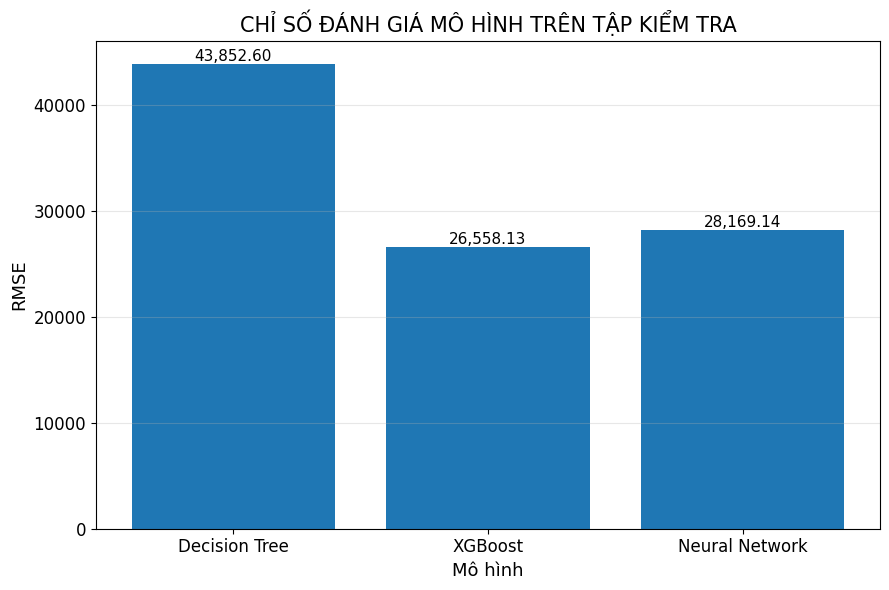

In [111]:
import matplotlib.pyplot as plt

models = [
    'Decision Tree',
    'XGBoost',
    'Neural Network'
]

rmse_values = [
    rmse_dt,
    rmse_xgb,
    rmse_nn
]

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.bar(models, rmse_values)

# Nhãn trục
ax.set_xlabel('Mô hình', fontsize=13)
ax.set_ylabel('RMSE', fontsize=13)

# Tiêu đề
ax.set_title(
    'CHỈ SỐ ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP KIỂM TRA',
    fontsize=15
)

# Tăng kích thước chữ trên trục X và Y
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

# Hiển thị số RMSE trên đầu mỗi cột
for bar, value in zip(bars, rmse_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{value:,.2f}',
        ha='center',
        va='bottom',
        fontsize=11
    )

ax.grid(axis='y', alpha=0.3)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR / 'model_rmse_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

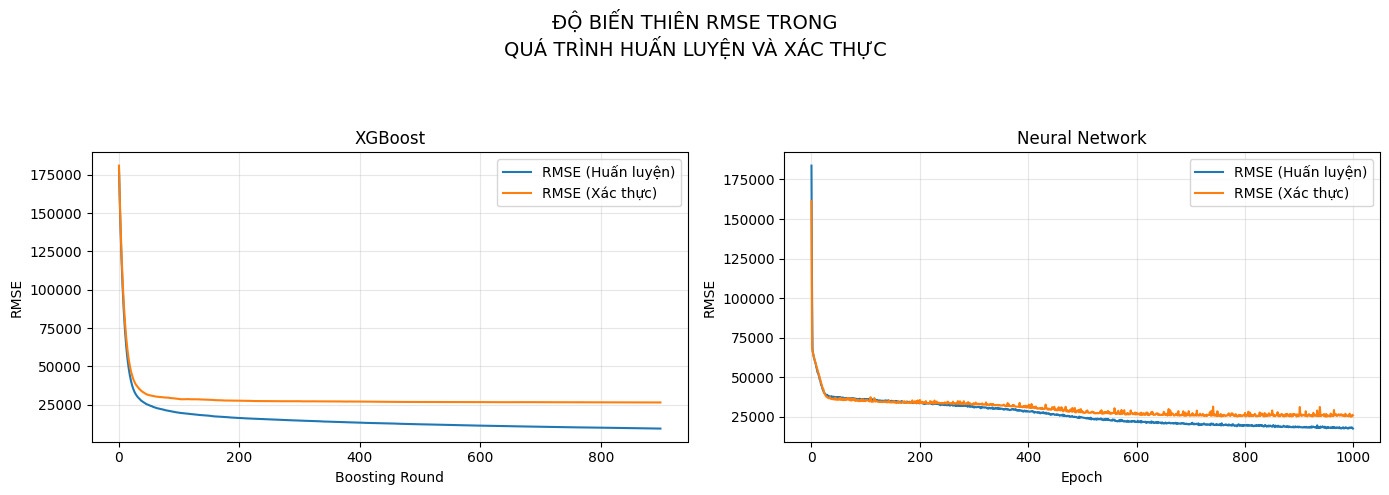

In [109]:
import matplotlib.pyplot as plt

# =========================
# Lấy kết quả XGBoost
# =========================
results = xgb_model.evals_result()

train_rmse_xgb = results['validation_0']['rmse']
val_rmse_xgb = results['validation_1']['rmse']


# =========================
# Tạo 2 biểu đồ cạnh nhau
# =========================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tiêu đề chung
fig.suptitle(
    'ĐỘ BIẾN THIÊN RMSE TRONG\n'
    'QUÁ TRÌNH HUẤN LUYỆN VÀ XÁC THỰC',
    fontsize=14
)


# =========================
# Biểu đồ XGBoost
# =========================
axes[0].plot(
    train_rmse_xgb,
    label='RMSE (Huấn luyện)'
)

axes[0].plot(
    val_rmse_xgb,
    label='RMSE (Xác thực)'
)

axes[0].set_xlabel('Boosting Round')
axes[0].set_ylabel('RMSE')
axes[0].set_title('XGBoost')
axes[0].legend()
axes[0].grid(True, alpha=0.3)


# =========================
# Biểu đồ Neural Network
# =========================
axes[1].plot(
    history.history['loss'],
    label='RMSE (Huấn luyện)'
)

axes[1].plot(
    history.history['val_loss'],
    label='RMSE (Xác thực)'
)

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('RMSE')
axes[1].set_title('Neural Network')
axes[1].legend()
axes[1].grid(True, alpha=0.3)


# =========================
# Hoàn thiện và lưu biểu đồ
# =========================
fig.tight_layout(rect=[0, 0, 1, 0.90])

fig.savefig(
    OUTPUT_DIR / 'xgb_nn_rmse_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()